# Unexpected Foundation Settlement — AI Risk Mapper

**A beginner-friendly, runnable Google Colab project**

This notebook shows how soil tests, groundwater, building loads and settlement sensors can be combined to answer four practical questions:

1. **Where** is settlement most likely?
2. **Why** is that location risky?
3. **How uncertain** is the prediction?
4. **What should an engineer inspect next?**

> This is a teaching prototype using simulated data. It is not a structural-safety decision tool. A qualified geotechnical/structural engineer must verify real projects.

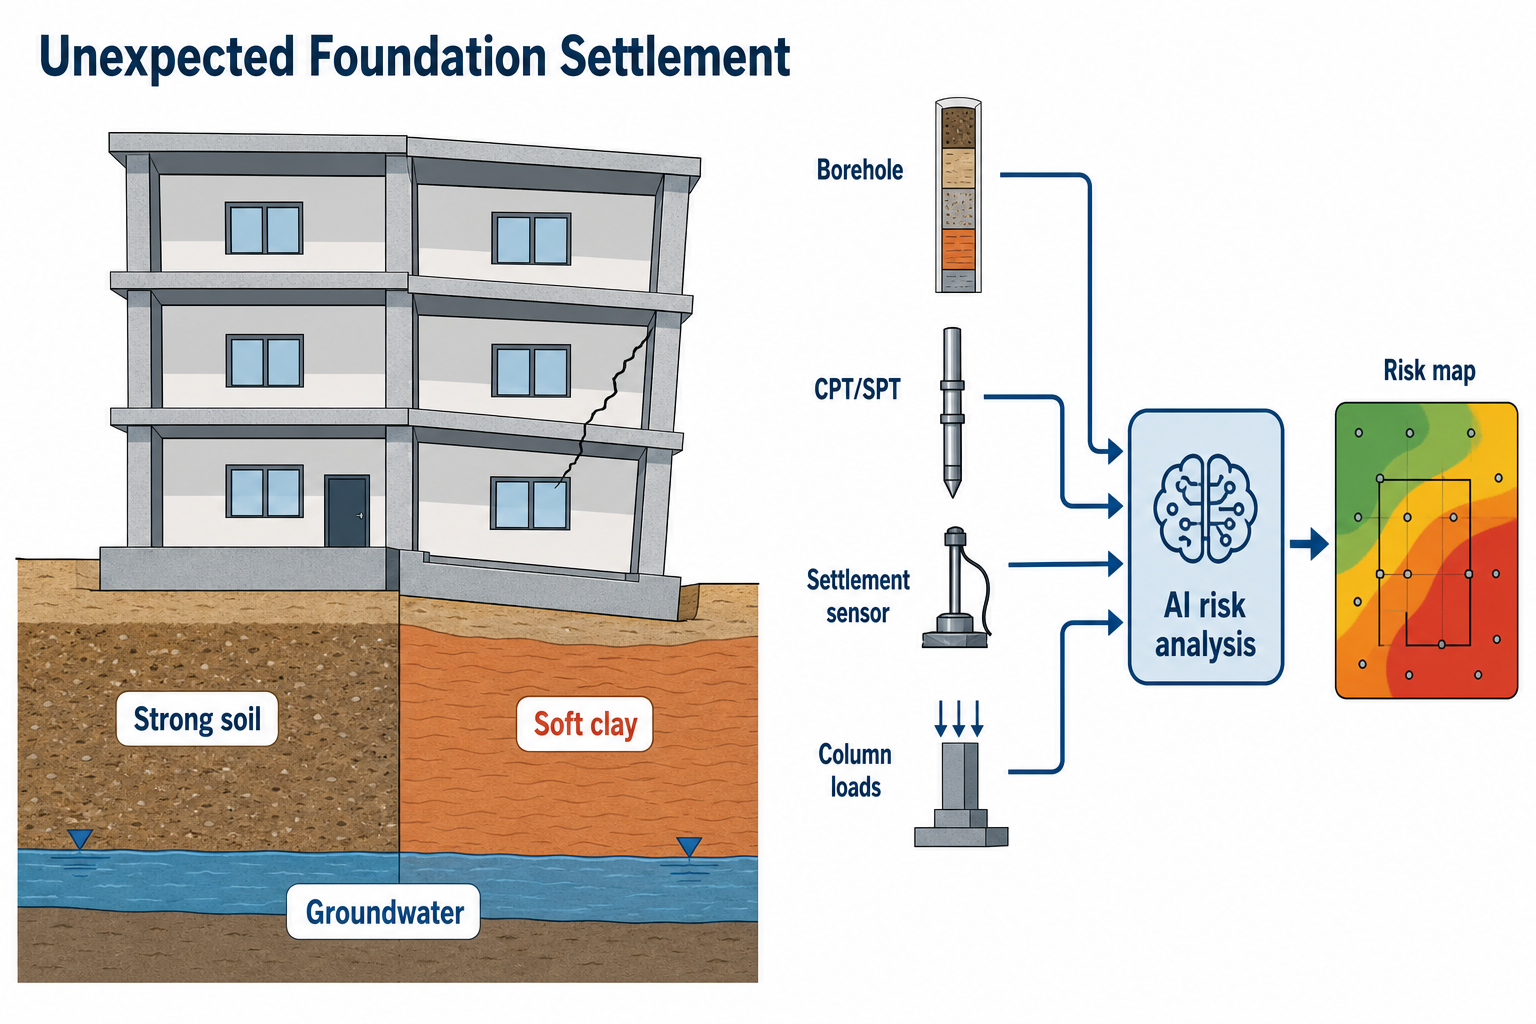

## 1 · The problem in one picture

Imagine a building like a table. Two legs stand on firm ground and two stand on soft mud. The mud side sinks more, so the table tilts. A building can do the same thing.

Uniform downward movement is **settlement**. Unequal movement from one side to another is **differential settlement**; this is often what causes cracking and distortion.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Circle
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

SEED = 42
rng = np.random.default_rng(SEED)
plt.style.use("seaborn-v0_8-whitegrid")

# A simple engineering illustration drawn with code, so it always works in Colab.
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.add_patch(Rectangle((0, 0), 12, 2.2, color="#b88655", alpha=.9))
ax.add_patch(Rectangle((0, 0), 5.8, 1.5, color="#806447", alpha=.85))
ax.add_patch(Rectangle((5.8, 0), 6.2, 1.5, color="#df7b45", alpha=.75))
ax.text(2.9, .8, "DENSE / STRONG SOIL", ha="center", color="white", weight="bold")
ax.text(8.9, .8, "SOFT CLAY POCKET", ha="center", color="white", weight="bold")
ax.add_patch(Rectangle((0, 0), 12, .32, color="#4da6d8"))
ax.text(6, .16, "GROUNDWATER", ha="center", va="center", color="white", weight="bold")

# Level left half and slightly settled right half.
ax.add_patch(Polygon([(1,2.2),(5.8,2.2),(5.8,2.55),(1,2.55)], color="#52616b"))
ax.add_patch(Polygon([(5.8,2.2),(11,1.85),(11,2.2),(5.8,2.55)], color="#52616b"))
for x, base, lean in [(1.5,2.55,0),(4.8,2.55,0),(6.3,2.51,.10),(10.3,2.23,.18)]:
    ax.add_patch(Polygon([(x,base),(x+.28,base),(x+.28+lean,4.8),(x+lean,4.8)], color="#8a99a6"))
ax.add_patch(Polygon([(1.4,4.8),(10.8,4.8),(10.55,5.15),(1.4,5.15)], color="#52616b"))
ax.plot([7.3,7.65,7.35,7.8],[4.4,3.9,3.4,2.9], color="#b52a2a", lw=3)
ax.annotate("Unequal movement → cracking", xy=(7.6,3.8), xytext=(8.6,4.45),
            arrowprops=dict(arrowstyle="->", color="#b52a2a"), color="#b52a2a", weight="bold")
ax.annotate("This side settles more", xy=(9.6,2.05), xytext=(8.2,2.75),
            arrowprops=dict(arrowstyle="->"), weight="bold")
ax.set(xlim=(0,12), ylim=(0,5.6), title="Why differential foundation settlement happens")
ax.axis("off")
plt.show()

## 2 · What information does the AI receive?

Each observation represents one monitored foundation location.

| Input | Simple meaning | Typical source |
|---|---|---|
| `spt_n` | Higher usually means denser/stronger soil | SPT field test |
| `cpt_qc_mpa` | Cone resistance; higher usually means stronger soil | CPT probe |
| `soft_clay_m` | Thickness of compressible clay | Borehole/CPT interpretation |
| `groundwater_depth_m` | Water depth below ground | Monitoring well |
| `groundwater_drop_m` | Recent lowering of groundwater | Repeated readings |
| `column_load_kn` | Load transferred at that foundation | Structural model |
| `foundation_width_m` | Width spreading the load | Drawings/as-built survey |
| `distance_to_borehole_m` | How far we are from measured soil information | Survey/GIS |
| `observed_settlement_mm` | What actually happened | Level survey/sensor |

The final column is the answer the model learns to estimate.

## 3 · Build a virtual site

Real site data is sensitive and often incomplete, so this notebook creates a believable synthetic site. The southeast area contains a soft-clay pocket. This hidden pattern is what the model must learn.

In [ ]:
n = 900
x = rng.uniform(0, 100, n)  # metres east
y = rng.uniform(0, 80, n)   # metres north

# A soft-soil pocket centred near (75, 20).
soft_zone = np.exp(-(((x-75)/22)**2 + ((y-20)/17)**2))
spt_n = np.clip(32 - 24*soft_zone + rng.normal(0, 3.5, n), 2, 55)
cpt_qc_mpa = np.clip(11 - 8*soft_zone + rng.normal(0, 1.2, n), .6, 22)
soft_clay_m = np.clip(1 + 8*soft_zone + rng.normal(0, .7, n), 0, 12)
groundwater_depth_m = np.clip(5.5 - 2.5*soft_zone + rng.normal(0, .65, n), .5, 10)
groundwater_drop_m = np.clip(rng.gamma(1.6, .45, n) + .7*soft_zone, 0, 4)
column_load_kn = rng.uniform(500, 2600, n)
foundation_width_m = rng.uniform(1.4, 3.8, n)

# Sparse boreholes: uncertainty increases farther from one.
boreholes = np.array([[8,8],[18,65],[48,38],[88,68],[92,12],[60,72]])
distance_to_borehole_m = np.min(np.sqrt((x[:,None]-boreholes[:,0])**2 +
                                         (y[:,None]-boreholes[:,1])**2), axis=1)

# A transparent teaching equation creates the target.
soil_weakness = (35-spt_n).clip(0) * .13 + (12-cpt_qc_mpa).clip(0) * .30
applied_pressure = column_load_kn / (foundation_width_m**2)
observed_settlement_mm = (
    1.8 + 0.52*soft_clay_m + 0.0085*applied_pressure
    + 1.35*groundwater_drop_m + .32*soil_weakness
    + 5.5*soft_zone + rng.normal(0, 1.7, n)
).clip(0)

df = pd.DataFrame({
    "x_m":x, "y_m":y, "spt_n":spt_n, "cpt_qc_mpa":cpt_qc_mpa,
    "soft_clay_m":soft_clay_m, "groundwater_depth_m":groundwater_depth_m,
    "groundwater_drop_m":groundwater_drop_m, "column_load_kn":column_load_kn,
    "foundation_width_m":foundation_width_m,
    "distance_to_borehole_m":distance_to_borehole_m,
    "observed_settlement_mm":observed_settlement_mm
})
df.head().round(2)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
s0 = ax[0].scatter(df.x_m, df.y_m, c=df.soft_clay_m, cmap="YlOrBr", s=18)
ax[0].scatter(boreholes[:,0], boreholes[:,1], marker="*", s=220, c="#143d59", label="Borehole")
ax[0].set_title("What we know: soft-clay thickness")
ax[0].legend(); fig.colorbar(s0, ax=ax[0], label="Soft clay (m)")
s1 = ax[1].scatter(df.x_m, df.y_m, c=df.observed_settlement_mm, cmap="RdYlGn_r", s=18)
ax[1].set_title("What happened: measured settlement")
fig.colorbar(s1, ax=ax[1], label="Settlement (mm)")
for a in ax: a.set(xlabel="East (m)", ylabel="North (m)", aspect="equal")
plt.tight_layout(); plt.show()

**Read the pictures like this:** the orange soil pocket in the southeast roughly matches the high-settlement area. But settlement is not controlled by soil alone; load, foundation size and groundwater also matter.

## 4 · Give the model useful engineering clues

Instead of asking the model to discover every physical relationship, we add **foundation pressure**: load divided by foundation area. This is an example of combining engineering knowledge with machine learning.

In [ ]:
df["foundation_pressure_kpa"] = df.column_load_kn / (df.foundation_width_m**2)

FEATURES = ["x_m", "y_m", "spt_n", "cpt_qc_mpa", "soft_clay_m",
            "groundwater_depth_m", "groundwater_drop_m", "column_load_kn",
            "foundation_width_m", "foundation_pressure_kpa", "distance_to_borehole_m"]
TARGET = "observed_settlement_mm"

train, test = train_test_split(df, test_size=.25, random_state=SEED)
print(f"Learning locations: {len(train)}")
print(f"Unseen test locations: {len(test)}")

## 5 · Train an explainable baseline model

A random forest learns many if/then rules and averages them. It handles nonlinear relationships well and is a useful baseline for tabular engineering data.

In [ ]:
model = RandomForestRegressor(
    n_estimators=220, min_samples_leaf=4, max_features=.8,
    random_state=SEED, n_jobs=-1
)
model.fit(train[FEATURES], train[TARGET])
pred = model.predict(test[FEATURES])

mae = mean_absolute_error(test[TARGET], pred)
r2 = r2_score(test[TARGET], pred)
print(f"Mean absolute error: {mae:.2f} mm")
print(f"R² on unseen locations: {r2:.3f}")

fig, ax = plt.subplots(figsize=(5.5,5))
ax.scatter(test[TARGET], pred, alpha=.55, color="#2878b5")
limit = max(test[TARGET].max(), pred.max())
ax.plot([0,limit],[0,limit], "--", color="#d1495b", label="Perfect prediction")
ax.set(xlabel="Measured settlement (mm)", ylabel="Predicted settlement (mm)",
       title="Does the model work on unseen locations?")
ax.legend(); plt.show()

## 6 · Ask why the model predicts settlement

Permutation importance measures how much the model gets worse when one input is shuffled. A larger bar means the input was more useful for prediction. It shows association—not proof of physical causation.

In [ ]:
imp = permutation_importance(model, test[FEATURES], test[TARGET],
                             n_repeats=8, random_state=SEED, n_jobs=-1)
importance = pd.Series(imp.importances_mean, index=FEATURES).sort_values()
importance.plot.barh(figsize=(8,5), color="#2a9d8f")
plt.title("Which clues changed the prediction most?")
plt.xlabel("Decrease in model score after shuffling")
plt.tight_layout(); plt.show()

## 7 · Produce a site risk map

Now we create a regular site grid. For demonstration, its soil and groundwater values come from the same virtual geology used above. In a real project, they would come from an interpolation/geostatistical model fitted only to actual borehole and CPT observations.

In [ ]:
gx, gy = np.meshgrid(np.linspace(0,100,55), np.linspace(0,80,45))
gsoft = np.exp(-(((gx.ravel()-75)/22)**2 + ((gy.ravel()-20)/17)**2))
grid = pd.DataFrame({"x_m":gx.ravel(), "y_m":gy.ravel()})
grid["spt_n"] = np.clip(32 - 24*gsoft, 2, 55)
grid["cpt_qc_mpa"] = np.clip(11 - 8*gsoft, .6, 22)
grid["soft_clay_m"] = np.clip(1 + 8*gsoft, 0, 12)
grid["groundwater_depth_m"] = np.clip(5.5 - 2.5*gsoft, .5, 10)
grid["groundwater_drop_m"] = .8 + .7*gsoft
grid["column_load_kn"] = 1700
grid["foundation_width_m"] = 2.4
grid["foundation_pressure_kpa"] = grid.column_load_kn / grid.foundation_width_m**2
grid["distance_to_borehole_m"] = np.min(
    np.sqrt((grid.x_m.to_numpy()[:,None]-boreholes[:,0])**2 +
            (grid.y_m.to_numpy()[:,None]-boreholes[:,1])**2), axis=1)
grid["predicted_mm"] = model.predict(grid[FEATURES])

# Model spread: individual trees disagree more where the forest is unsure.
tree_predictions = np.vstack([tree.predict(grid[FEATURES].to_numpy()) for tree in model.estimators_])
grid["model_spread_mm"] = tree_predictions.std(axis=0)

# Practical confidence penalty: sparse ground investigation means greater uncertainty.
grid["uncertainty_index"] = (
    .55 * np.clip(grid.model_spread_mm / grid.model_spread_mm.quantile(.95), 0, 1)
    + .45 * np.clip(grid.distance_to_borehole_m / 35, 0, 1)
)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14,5.2))
z1 = grid.predicted_mm.to_numpy().reshape(gx.shape)
z2 = grid.uncertainty_index.to_numpy().reshape(gx.shape)
c1 = ax[0].contourf(gx, gy, z1, 18, cmap="RdYlGn_r")
fig.colorbar(c1, ax=ax[0], label="Predicted settlement (mm)")
ax[0].set_title("Settlement risk map")
c2 = ax[1].contourf(gx, gy, z2, 18, cmap="magma_r")
fig.colorbar(c2, ax=ax[1], label="Uncertainty index")
ax[1].set_title("Where the model needs more evidence")
for a in ax:
    a.scatter(boreholes[:,0], boreholes[:,1], marker="*", s=160, c="#00d4ff",
              edgecolor="black", label="Borehole")
    a.set(xlabel="East (m)", ylabel="North (m)", aspect="equal")
    a.legend(loc="upper left")
plt.tight_layout(); plt.show()

**Two maps must be read together.** A red risk zone tells us where settlement may be high. The uncertainty map tells us how much evidence supports that statement. High risk plus high uncertainty is often a good place for the next investigation—not an automatic repair decision.

## 8 · Turn numbers into an engineer-friendly recommendation

The function below predicts one location and lists evidence. The thresholds are deliberately simple teaching rules; a real system must use project-specific limits and applicable standards.

In [ ]:
def assess_location(spt_n, cpt_qc_mpa, soft_clay_m, groundwater_depth_m,
                    groundwater_drop_m, column_load_kn, foundation_width_m,
                    x_m=75, y_m=20, distance_to_borehole_m=28):
    pressure = column_load_kn / foundation_width_m**2
    row = pd.DataFrame([{
        "x_m":x_m, "y_m":y_m, "spt_n":spt_n, "cpt_qc_mpa":cpt_qc_mpa,
        "soft_clay_m":soft_clay_m, "groundwater_depth_m":groundwater_depth_m,
        "groundwater_drop_m":groundwater_drop_m, "column_load_kn":column_load_kn,
        "foundation_width_m":foundation_width_m,
        "foundation_pressure_kpa":pressure,
        "distance_to_borehole_m":distance_to_borehole_m
    }])
    estimate = float(model.predict(row[FEATURES])[0])
    reasons = []
    if soft_clay_m > 5: reasons.append("thick compressible clay")
    if spt_n < 12: reasons.append("low SPT resistance")
    if cpt_qc_mpa < 4: reasons.append("low CPT cone resistance")
    if groundwater_drop_m > 1.2: reasons.append("large recent groundwater drop")
    if pressure > 350: reasons.append("high foundation pressure")
    if distance_to_borehole_m > 20: reasons.append("limited nearby soil information")
    band = "HIGH" if estimate >= 18 else "MODERATE" if estimate >= 10 else "LOW"
    next_step = ("Add CPT/borehole or monitoring near this location before choosing a repair."
                 if distance_to_borehole_m > 20
                 else "Review sensor trend and perform soil–foundation analysis.")
    return {"predicted_settlement_mm":round(estimate,1), "screening_band":band,
            "main_evidence":reasons or ["no simple warning rule triggered"],
            "suggested_next_check":next_step}

assess_location(spt_n=7, cpt_qc_mpa=2.5, soft_clay_m=8.2,
                groundwater_depth_m=2.8, groundwater_drop_m=1.7,
                column_load_kn=2200, foundation_width_m=2.1)

## 9 · What would change for real data?

Replace the simulated table with one row per foundation/grid point and keep units consistent. Real projects also need:

- Time-aware validation: train on earlier monitoring periods and test on later periods.
- Spatial validation: hold out entire areas—not random nearby points—to avoid overly optimistic results.
- Missing-value checks, instrument calibration records and impossible-value rules.
- Geotechnical interpretation of soil layers and groundwater conditions.
- Predictions with uncertainty ranges, not only single numbers.
- Independent verification against settlement calculations and field investigation.
- Versioned data, model and review records so every conclusion is auditable.

### Minimum useful prototype

1. Import borehole/CPT, foundation-load and monitoring CSV files.
2. Standardize coordinates and units.
3. Join each monitored foundation to nearby ground-investigation data.
4. Train a baseline model and compare it with a conventional settlement calculation.
5. Show predicted settlement, uncertainty and distance to evidence on a site map.
6. Let the engineer approve, reject or annotate each suggested investigation.

## 10 · Final takeaway

The AI is not replacing the engineer. Its job is to organize scattered evidence and say:

> **“This area may settle more because the clay is thick, the soil resistance is low, the load is high and groundwater changed. Evidence is sparse here, so investigate this location next.”**

That can save engineers time while keeping the safety decision with qualified professionals.